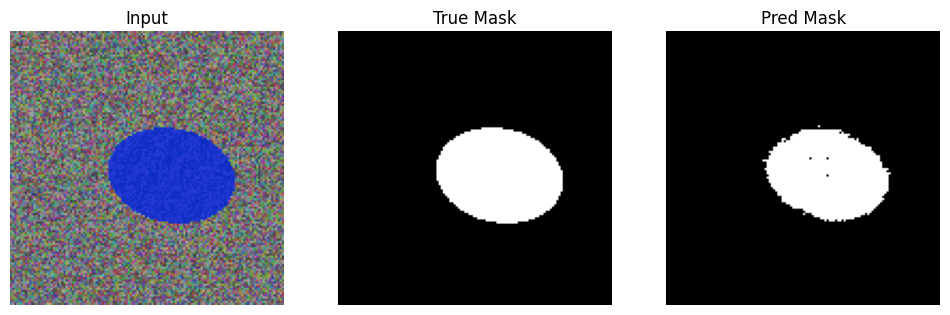


Epoch 25 — val_loss: 0.0584
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.9936 - loss: 0.0358 - val_accuracy: 0.9864 - val_loss: 0.0584
🔍 Тест на НОВОМ изображении (seed=999 — не использовался при обучении):


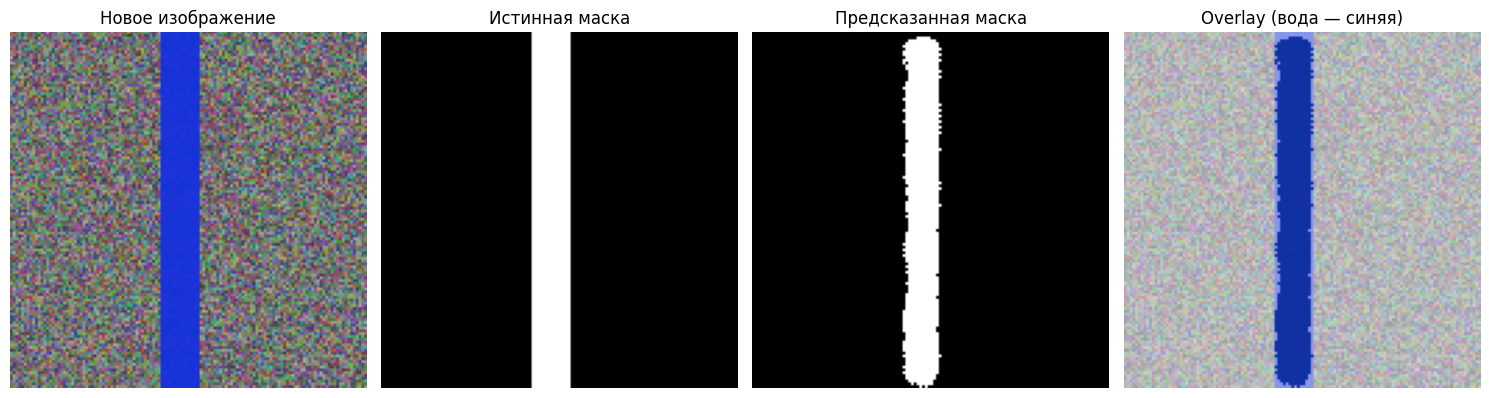

🎯 IoU на новом изображении: 0.837 (83.7%)


In [ ]:
# ==============================
# 0. Импорты
# ==============================
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import math
import random

print("TensorFlow version:", tf.__version__)

# ==============================
# 1. Генерация синтетических изображений с водоёмами
# ==============================
IMG_SIZE = 128
NUM_SAMPLES = 200  # ≥100 — по условию задания

def generate_water_image_and_mask(seed=None):
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)

    # 1. Фон: зелёно-коричневый шум (имитация леса/поля)
    image = np.random.uniform(0.2, 0.7, (IMG_SIZE, IMG_SIZE, 3))
    # добавим немного структуры
    for _ in range(5):
        cx, cy = np.random.randint(0, IMG_SIZE, 2)
        r = np.random.randint(5, 20)
        intensity = np.random.uniform(0.1, 0.3)
        for x in range(max(0, cx - r), min(IMG_SIZE, cx + r)):
            for y in range(max(0, cy - r), min(IMG_SIZE, cy + r)):
                d = math.sqrt((x - cx)**2 + (y - cy)**2)
                if d < r:
                    alpha = (1 - d / r) * intensity
                    image[x, y] += np.array([0.0, 0.1, -0.1]) * alpha  # чуть синевы/зелени

    # 2. Водоём: эллипс (озеро) или прямоугольник (река)
    mask = np.zeros((IMG_SIZE, IMG_SIZE, 1), dtype=np.uint8)

    if random.random() < 0.7:  # 70% — озёра (эллипсы)
        cx = np.random.randint(30, IMG_SIZE - 30)
        cy = np.random.randint(30, IMG_SIZE - 30)
        a = np.random.randint(15, 35)  # полуось X
        b = np.random.randint(10, 30)  # полуось Y
        angle = np.random.uniform(0, 2 * math.pi)

        cos_a = math.cos(angle)
        sin_a = math.sin(angle)

        for x in range(IMG_SIZE):
            for y in range(IMG_SIZE):
                dx = x - cx
                dy = y - cy
                # поворот обратно
                xr = dx * cos_a + dy * sin_a
                yr = -dx * sin_a + dy * cos_a
                if (xr / a)**2 + (yr / b)**2 <= 1.0:
                    mask[x, y] = 1
                    # вода: синяя, с лёгкой рябью
                    ripple = 0.05 * math.sin(0.3 * dx + 0.4 * dy + random.random() * 10)
                    image[x, y] = [
                        0.1 + ripple,      # R — тёмно-синий
                        0.2 + ripple * 0.5, # G
                        0.8 + ripple        # B — доминирует
                    ]
    else:  # 30% — реки (горизонтальные/вертикальные полосы)
        if random.random() < 0.5:
            # горизонтальная река
            y0 = np.random.randint(40, IMG_SIZE - 40)
            width = np.random.randint(8, 20)
            for y in range(max(0, y0 - width//2), min(IMG_SIZE, y0 + width//2)):
                for x in range(IMG_SIZE):
                    mask[x, y] = 1
                    ripple = 0.03 * math.sin(0.5 * x + random.random() * 5)
                    image[x, y] = [0.1 + ripple, 0.2, 0.85 + ripple * 0.5]
        else:
            # вертикальная река
            x0 = np.random.randint(40, IMG_SIZE - 40)
            width = np.random.randint(8, 20)
            for x in range(max(0, x0 - width//2), min(IMG_SIZE, x0 + width//2)):
                for y in range(IMG_SIZE):
                    mask[x, y] = 1
                    ripple = 0.03 * math.sin(0.5 * y + random.random() * 5)
                    image[x, y] = [0.1 + ripple, 0.15, 0.8 + ripple * 0.5]

    image = np.clip(image, 0.0, 1.0)
    return image.astype(np.float32), mask.astype(np.int32)

# Проверка генерации
print("Генерация примеров...")
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(4):
    img, msk = generate_water_image_and_mask(seed=42 + i)
    axes[0, i].imshow(img)
    axes[0, i].set_title("Изображение")
    axes[0, i].axis('off')
    axes[1, i].imshow(msk[:, :, 0], cmap='gray')
    axes[1, i].set_title("Маска (вода=1)")
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

# ==============================
# 2. Создание tf.data.Dataset из генератора
# ==============================
def synthetic_water_generator():
    for i in range(NUM_SAMPLES):
        img, msk = generate_water_image_and_mask(seed=i)
        yield img, msk

# Определяем output_signature
output_signature = (
    tf.TensorSpec(shape=(IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32),
    tf.TensorSpec(shape=(IMG_SIZE, IMG_SIZE, 1), dtype=tf.int32)
)

dataset = tf.data.Dataset.from_generator(
    synthetic_water_generator,
    output_signature=output_signature
)

# Разбиваем на train / test
DATASET_SIZE = NUM_SAMPLES
TRAIN_SIZE = int(0.8 * DATASET_SIZE)

train_ds = dataset.take(TRAIN_SIZE).cache().shuffle(50).batch(16).repeat().prefetch(tf.data.AUTOTUNE)
test_ds = dataset.skip(TRAIN_SIZE).batch(16)

print(f"Создано: {NUM_SAMPLES} синтетических изображений (водоёмы)")
print(f"Train: {TRAIN_SIZE}, Test: {DATASET_SIZE - TRAIN_SIZE}")

# ==============================
# 3. Подготовка U-Net (повторяем структуру из методички)
# ==============================
# Энкодер — MobileNetV2 (заморожен сначала)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=[IMG_SIZE, IMG_SIZE, 3],
    include_top=False
)

layer_names = [
    'block_1_expand_relu',   # 64x64
    'block_3_expand_relu',   # 32x32
    'block_6_expand_relu',   # 16x16
    'block_13_expand_relu',  # 8x8
    'block_16_project',      # 4x4
]
base_model_outputs = [base_model.get_layer(name).output for name in layer_names]
down_stack = tf.keras.Model(inputs=base_model.input, outputs=base_model_outputs)
down_stack.trainable = False  # сначала заморожен

# Декодер
def upsample(filters, size, apply_dropout=False):
    initializer = tf.random_normal_initializer(0., 0.02)
    result = tf.keras.Sequential()
    result.add(
        tf.keras.layers.Conv2DTranspose(
            filters, size, strides=2,
            padding='same',
            kernel_initializer=initializer,
            use_bias=False
        )
    )
    result.add(tf.keras.layers.BatchNormalization())
    if apply_dropout:
        result.add(tf.keras.layers.Dropout(0.5))
    result.add(tf.keras.layers.ReLU())
    return result

def unet_model(output_channels: int, apply_dropout=False):
    up_stack = [
        upsample(512, 3, apply_dropout=apply_dropout),
        upsample(256, 3, apply_dropout=apply_dropout),
        upsample(128, 3, apply_dropout=apply_dropout),
        upsample(64,  3, apply_dropout=apply_dropout),
    ]
    inputs = tf.keras.layers.Input(shape=[IMG_SIZE, IMG_SIZE, 3])
    skips = down_stack(inputs)
    x = skips[-1]
    skips = reversed(skips[:-1])
    for up, skip in zip(up_stack, skips):
        x = up(x)
        x = tf.keras.layers.Concatenate()([x, skip])
    last = tf.keras.layers.Conv2DTranspose(
        filters=output_channels, kernel_size=3, strides=2, padding='same'
    )
    x = last(x)
    return tf.keras.Model(inputs=inputs, outputs=x)

# ==============================
# 4. Исправленный DisplayCallback (без ошибки!)
# ==============================
class DisplayCallback(tf.keras.callbacks.Callback):
    def __init__(self, dataset):
        super().__init__()
        self.dataset = dataset

    def on_epoch_end(self, epoch, logs=None):
        clear_output(wait=True)
        self.show_predictions()
        print(f'\nEpoch {epoch+1} — val_loss: {logs["val_loss"]:.4f}')

    def show_predictions(self):
        for image_batch, mask_batch in self.dataset.take(1):
            pred = self.model.predict(image_batch, verbose=0)
            img = image_batch[0]
            true_mask = mask_batch[0]
            pred_mask = self.create_mask(pred[0])
            self.display([img, true_mask, pred_mask])
            break

    def create_mask(self, pred_mask):
        pred_mask = tf.math.argmax(pred_mask, axis=-1)
        pred_mask = pred_mask[..., tf.newaxis]
        return pred_mask

    @staticmethod
    def display(display_list):
        plt.figure(figsize=(12, 4))
        titles = ['Input', 'True Mask', 'Pred Mask']
        for i, (img, title) in enumerate(zip(display_list, titles)):
            plt.subplot(1, 3, i+1)
            plt.title(title)
            if i == 1 or i == 2:
                plt.imshow(img[:, :, 0], cmap='gray')
            else:
                plt.imshow(img)
            plt.axis('off')
        plt.show()

# ==============================
# 5. Создание и обучение модели
# ==============================
OUTPUT_CLASSES = 2  # бинарная: 0 — фон, 1 — вода

model = unet_model(OUTPUT_CLASSES, apply_dropout=True)

# Разморозим энкодер для fine-tuning (полезно при малом датасете)
down_stack.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print("Модель собрана. Начинаем обучение...")

EPOCHS = 25
STEPS_PER_EPOCH = TRAIN_SIZE // 16
VALIDATION_STEPS = (DATASET_SIZE - TRAIN_SIZE) // 16

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_data=test_ds,
    validation_steps=VALIDATION_STEPS,
    callbacks=[DisplayCallback(test_ds)],
    verbose=1
)

# ==============================
# 6. Тест на новом сгенерированном изображении (не из датасета!)
# ==============================
print("🔍 Тест на НОВОМ изображении (seed=999 — не использовался при обучении):")
test_image, test_mask = generate_water_image_and_mask(seed=999)
test_image_batch = tf.expand_dims(test_image, axis=0)  # (1,128,128,3)

pred_logits = model.predict(test_image_batch, verbose=0)
pred_mask = tf.math.argmax(pred_logits[0], axis=-1)[..., tf.newaxis]

# Визуализация
plt.figure(figsize=(15, 4))
plt.subplot(1, 4, 1)
plt.title("Новое изображение")
plt.imshow(test_image)
plt.axis('off')

plt.subplot(1, 4, 2)
plt.title("Истинная маска")
plt.imshow(test_mask[:, :, 0], cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.title("Предсказанная маска")
plt.imshow(pred_mask[:, :, 0], cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.title("Overlay (вода — синяя)")
plt.imshow(test_image)
plt.imshow(pred_mask[:, :, 0], cmap='Blues', alpha=0.5)
plt.axis('off')

plt.tight_layout()
plt.show()

# Вычислим IoU для этого примера
intersection = np.logical_and(test_mask[:, :, 0], pred_mask[:, :, 0]).sum()
union = np.logical_or(test_mask[:, :, 0], pred_mask[:, :, 0]).sum()
iou = intersection / union if union > 0 else 0
print(f"🎯 IoU на новом изображении: {iou:.3f} ({iou*100:.1f}%)")